# Notebook 1: Dataset Overview

This notebook is the first step in the analysis because it helps us understand the **shape, coverage, and basic structure** of the query dataset before making any behavioral claims.

We are doing this for three reasons:

1. **Quality check**: make sure the cleaned dataset loaded correctly and key columns are present.
2. **Descriptive context**: report how many participants, weeks, and queries are in the data.
3. **Research grounding**: later analyses about behavior patterns, change over time, or user differences need a baseline summary first.

In other words, this notebook answers: **What data do we actually have?**

## 1. Import packages

We start by importing the main Python libraries for data loading, cleaning, and visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# show more columns when needed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)

## 2. Load the cleaned dataset

This notebook assumes you already created the cleaned file with the final labels:

- `participant_no`
- `week_no`
- `query`
- `final_type`
- `final_task`
- `final_goal`

These are the minimum fields needed for all later notebooks.

In [5]:
file_path = '../Reconciled_Final.csv'
df = pd.read_csv(file_path)

print('Shape:', df.shape)
df.head()

Shape: (2115, 6)


,participant_no,week_no,query,final_type,final_task,final_goal
0,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
1,102,Week 1,foods to avoid while losing body fat,ideas/options,option seeking,plan
2,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
3,102,Week 1,foods to eat that help lose weight,ideas/options,option seeking,plan
4,102,Week 1,vegan foods to eat that help lose weight,ideas/options,option seeking,plan


## 3. Quick structure check

Before analyzing anything, we verify the columns and missingness.

Why this matters:
- If key variables are missing, later analyses may be misleading.
- This also confirms whether the reconciliation and final-label pipeline worked as expected.

In [6]:
df.columns.tolist()

['participant_no',
 'week_no',
 'query',
 'final_type',
 'final_task',
 'final_goal']

In [7]:
required_cols = ['participant_no', 'week_no', 'query', 'final_type', 'final_task', 'final_goal']

missing_required = [c for c in required_cols if c not in df.columns]
print('Missing required columns:', missing_required)

df[required_cols].isna().sum()

Missing required columns: []


participant_no    0
week_no           0
query             0
final_type        0
final_task        0
final_goal        0
dtype: int64

## 4. Basic dataset counts

This section gives the most important high-level description of the dataset.

Questions answered here:
- How many total queries are there?
- How many unique participants are represented?
- How many weeks are included?
- What is the average number of queries per participant?

These numbers are useful in the methods or results section of a paper or presentation.

In [8]:
n_queries = len(df)
n_participants = df['participant_no'].nunique(dropna=True)
n_weeks = df['week_no'].nunique(dropna=True)
queries_per_participant = df.groupby('participant_no').size()

summary_table = pd.DataFrame({
    'metric': [
        'total_queries',
        'unique_participants',
        'unique_weeks',
        'avg_queries_per_participant',
        'median_queries_per_participant',
        'min_queries_per_participant',
        'max_queries_per_participant'
    ],
    'value': [
        n_queries,
        n_participants,
        n_weeks,
        queries_per_participant.mean(),
        queries_per_participant.median(),
        queries_per_participant.min(),
        queries_per_participant.max()
    ]
})

summary_table

,metric,value
0,total_queries,2115.000000
1,unique_participants,23.000000
2,unique_weeks,4.000000
3,avg_queries_per_participant,91.956522
4,median_queries_per_participant,70.000000
5,min_queries_per_participant,23.000000
6,max_queries_per_participant,253.000000


## 5. Queries by week

Now we look at how many queries appear in each week.

Why this matters:
- It tells us whether data collection is balanced across time.
- If some weeks have far fewer queries, then later week-based comparisons should be interpreted carefully.
- This is also the first step before studying **behavior change over time**.

In [9]:
queries_by_week = df.groupby('week_no').size().reset_index(name='n_queries')
queries_by_week = queries_by_week.sort_values('week_no')
queries_by_week

,week_no,n_queries
0,Week 1,258
1,Week 2,380
2,Week 3,863
3,Week 4,614


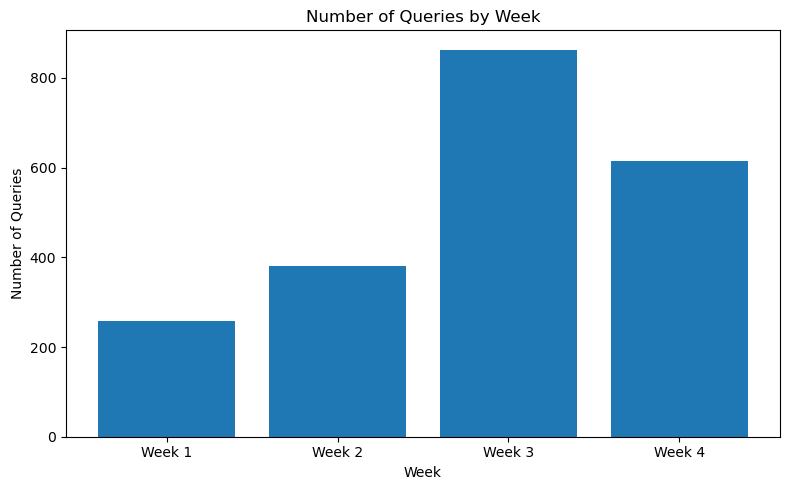

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(queries_by_week['week_no'].astype(str), queries_by_week['n_queries'])
plt.title('Number of Queries by Week')
plt.xlabel('Week')
plt.ylabel('Number of Queries')
plt.tight_layout()
plt.show()

## 6. Queries by participant

Here we examine participation intensity.

Why this matters:
- Some users may contribute many more queries than others.
- Heavy users can dominate overall patterns.
- This helps us decide whether later analyses should be done at the **query level** or the **participant level**.

In [11]:
queries_by_participant = df.groupby('participant_no').size().reset_index(name='n_queries')
queries_by_participant = queries_by_participant.sort_values('n_queries', ascending=False)
queries_by_participant.head(15)

,participant_no,n_queries
4,109,253
18,130,233
0,102,201
6,112,179
7,113,147
16,127,142
8,114,115
13,121,87
11,119,87
17,128,80


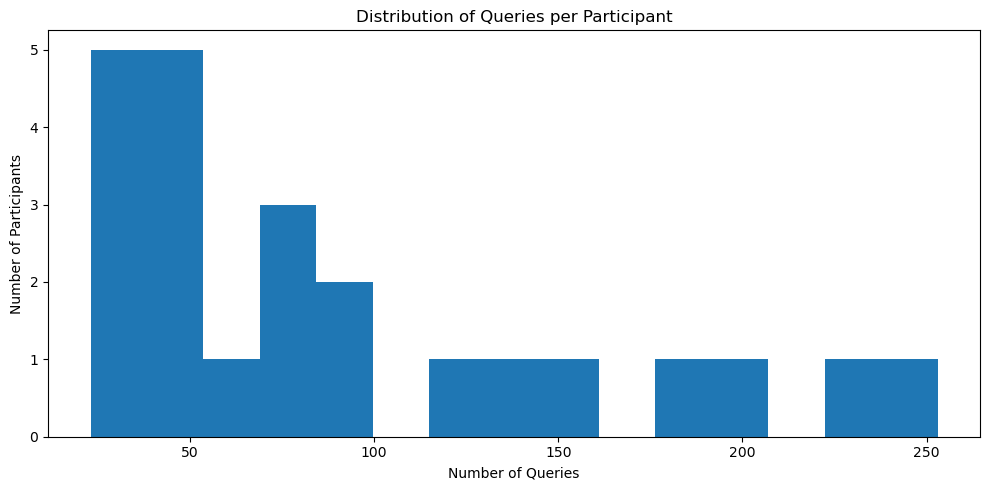

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(queries_by_participant['n_queries'], bins=15)
plt.title('Distribution of Queries per Participant')
plt.xlabel('Number of Queries')
plt.ylabel('Number of Participants')
plt.tight_layout()
plt.show()

## 7. Coverage table: participant × week

This table shows whether participation is evenly spread across weeks.

Why this matters:
- It helps identify missing weeks.
- It shows whether some people only appear early or late.
- This is very useful before doing any longitudinal analysis.

In [13]:
participant_week = pd.crosstab(df['participant_no'], df['week_no'])
participant_week

week_no,Week 1,Week 2,Week 3,Week 4
participant_no,,,,
102,27,56,68,50
103,0,0,39,0
107,0,0,0,37
108,0,0,49,0
109,0,0,253,0
111,0,0,42,0
112,0,0,179,0
113,17,33,21,76
114,17,37,28,33


## 8. Label distributions

Although deeper behavioral analysis comes later, it is useful to inspect the basic distribution of the final labels now.

Why this matters:
- It reveals whether some labels are extremely rare.
- It tells us whether the dataset is balanced enough for later comparisons.
- It also provides a first descriptive picture of user behavior.

In [14]:
type_counts = df['final_type'].value_counts(dropna=False).reset_index()
type_counts.columns = ['final_type', 'count']
type_counts['percent'] = type_counts['count'] / len(df) * 100
type_counts

,final_type,count,percent
0,ideas/options,889,42.033097
1,factual,273,12.907801
2,na,213,10.070922
3,outcome expectancy,145,6.855792
4,how-to (procedural),118,5.579196
5,outcome,110,5.200946
6,experiential,76,3.593381
7,normative,69,3.262411
8,utility,60,2.836879
9,how-to (psychological),45,2.127660


In [15]:
task_counts = df['final_task'].value_counts(dropna=False).reset_index()
task_counts.columns = ['final_task', 'count']
task_counts['percent'] = task_counts['count'] / len(df) * 100
task_counts

,final_task,count,percent
0,option seeking,835,39.479905
1,learn,709,33.522459
2,na,225,10.638298
3,evaluate,138,6.524823
4,logistics,76,3.593381
5,barrier management,70,3.309693
6,perform,41,1.938534
7,barrier,16,0.756501
8,barrier,4,0.189125
9,evalute,1,0.047281


In [16]:
goal_counts = df['final_goal'].value_counts(dropna=False).reset_index()
goal_counts.columns = ['final_goal', 'count']
goal_counts['percent'] = goal_counts['count'] / len(df) * 100
goal_counts

,final_goal,count,percent
0,plan,1278,60.425532
1,decision making,263,12.434988
2,na,205,9.692671
3,motivational reasoning,174,8.226950
4,action,118,5.579196
5,motivational,62,2.931442
6,decision,8,0.378251
7,motivational,7,0.330969


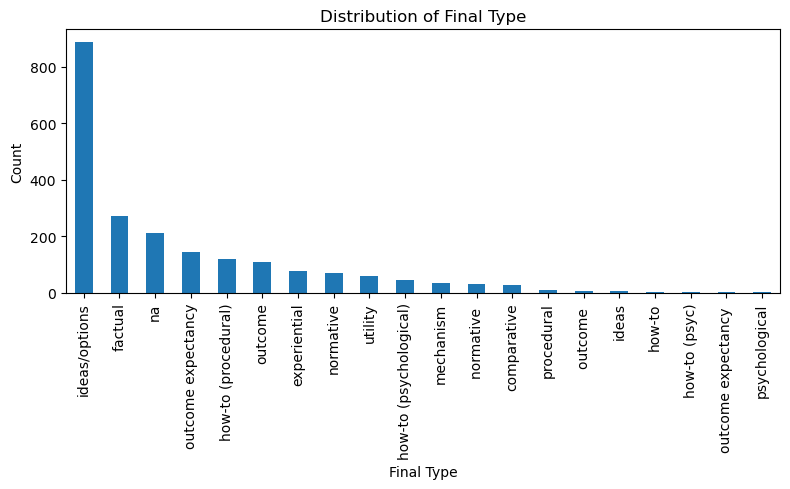

In [17]:
plt.figure(figsize=(8, 5))
df['final_type'].value_counts().plot(kind='bar')
plt.title('Distribution of Final Type')
plt.xlabel('Final Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

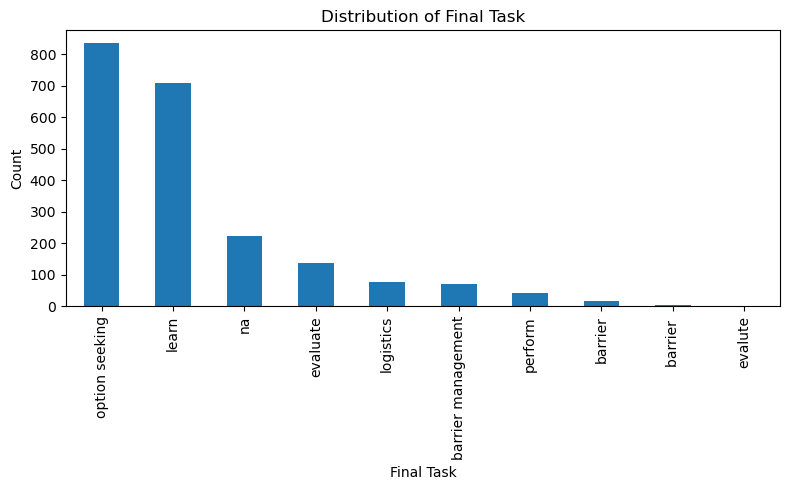

In [18]:
plt.figure(figsize=(8, 5))
df['final_task'].value_counts().plot(kind='bar')
plt.title('Distribution of Final Task')
plt.xlabel('Final Task')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

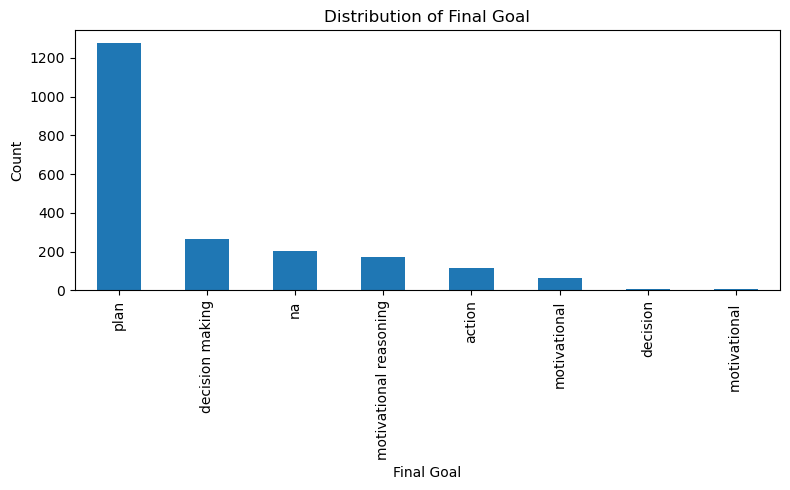

In [19]:
plt.figure(figsize=(8, 5))
df['final_goal'].value_counts().plot(kind='bar')
plt.title('Distribution of Final Goal')
plt.xlabel('Final Goal')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 9. Example queries

Before moving into more formal analysis, it is useful to inspect a few real examples.

Why this matters:
- It keeps the analysis grounded in actual user language.
- It helps verify whether the labels look reasonable.
- It can inspire stronger qualitative interpretations later.

In [20]:
df[['participant_no', 'week_no', 'query', 'final_type', 'final_task', 'final_goal']].sample(min(10, len(df)), random_state=42)

,participant_no,week_no,query,final_type,final_task,final_goal
1617,130,Week 1,walking for weight loss,outcome expectancy,learn,plan
1471,127,Week 3,easy to make recipes,ideas/options,option seeking,plan
259,119,Week 4,yoga vs. weights over 50 woman,comparative,evaluate,decision making
432,109,Week 3,fried rice recipe easy,ideas/options,option seeking,plan
1506,128,Week 1,pilates moves list,ideas/options,option seeking,plan
438,109,Week 3,making stir fry noodles,ideas/options,option seeking,plan
1064,114,Week 3,how to have a balanced diet,how-to (procedural),barrier management,plan
715,112,Week 3,red lobster gf biscuit recipe,ideas/options,option seeking,plan
873,113,Week 2,crab walks triggers what muscles groups,factual,learn,plan
1185,121,Week 2,albany ny,na,na,na


## 10. Takeaways from Notebook 1

By the end of this notebook, you should know:

- how large the dataset is,
- whether the data are complete enough for analysis,
- whether participants and weeks are balanced,
- and the basic distributions of final type, task, and goal.

This notebook creates the descriptive foundation for the next notebooks on:

- query behavior patterns,
- type-task-goal relationships,
- and change across weeks.